In [41]:
# =======================================
# 0. Import & cấu hình cơ bản
# =======================================
import os
import re
import glob
from typing import Dict, List, Optional

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# =======================================
# 0.1. Paths
# =======================================
DATA_DIR = "output_final_fixed"          # TODO: sửa lại cho đúng thư mục CSV điểm của bạn
WEIGHTS_FILE = "./weight/weights_used.csv"
OUTPUT_DIR = "./output_final_v2"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# File behavior / survey dùng để tạo feature theo course_code
BEHAVIOR_FILE = "clean_student_data_v2.csv"   # TODO: sửa lại nếu cần

# =======================================
# 1. Định nghĩa schema chuẩn & alias
# =======================================

TARGET_COL = "final"

# Giữ đủ biến thể quiz/homework theo yêu cầu của bạn
FEATURE_SCORE_COLS = [
    "attend",

    # quiz variants
    "quiz",
    "quiz1",
    "quiz2",

    "midterm",

    # homework variants
    "homework",
    "homework1",
    "homework2",

    "group_project",
    "individual_project",
    "practice",
    "regular",
    "speech_and_discussion",
    "project",
]

CANONICAL_FEATURES = FEATURE_SCORE_COLS + [TARGET_COL]

ID_COLUMNS = ["student_id", "course_code", "no"]

COLUMN_ALIASES: Dict[str, List[str]] = {
    "no": ["no", "No", "stt", "index"],

    "student_id": ["student id", "student_id", "id", "studentcode", "student_code"],
    "course_code": ["course_code", "course code", "course", "subject", "subject_code"],

    "attend": ["attend", "attendance"],

    # quiz
    "quiz": ["quiz"],
    "quiz1": ["quiz1", "quiz_1"],
    "quiz2": ["quiz2", "quiz_2"],

    # homework
    "homework": ["homework", "hw", "assignment"],
    "homework1": ["homework1", "hw1", "assignment1", "homework_1"],
    "homework2": ["homework2", "hw2", "assignment2", "homework_2"],

    "midterm": ["midterm", "mid term"],

    "group_project": ["group project", "group_project"],
    "individual_project": ["individual project", "individual_project"],

    "practice": ["practice", "lab", "exercise"],
    "regular": ["regular", "participation", "classwork"],

    "speech_and_discussion": ["speech and discussion", "speech_and_discussion", "discussion"],

    "project": ["project"],

    "final": ["final", "final_exam", "final exam", "endterm", "end_term"]
}

def normalize_col_name(col: str) -> str:
    """Chuẩn hóa tên cột: lower, strip, thay space bằng '_'."""
    return re.sub(r"\s+", "_", str(col).strip().lower())

def find_canonical_for_raw(raw_col: str) -> Optional[str]:
    """Tìm xem cột raw (sau normalize) map được vào canonical nào."""
    raw_norm = normalize_col_name(raw_col)
    for canonical, aliases in COLUMN_ALIASES.items():
        for alias in aliases:
            if raw_norm == normalize_col_name(alias):
                return canonical
    return None

def rename_raw_to_canonical(df_raw: pd.DataFrame) -> pd.DataFrame:
    """
    Đổi tên các cột raw (đã được normalize) sang canonical nếu match alias.
    Tránh overwrite khi canonical đã tồn tại.
    """
    rename_map = {}
    existing = set(df_raw.columns)

    for c in df_raw.columns:
        canonical = find_canonical_for_raw(c)
        if canonical and canonical not in existing:
            rename_map[c] = canonical

    if rename_map:
        df_raw = df_raw.rename(columns=rename_map)

    return df_raw

def get_num_col(df: pd.DataFrame, col: str) -> pd.Series:
    if col in df.columns:
        return pd.to_numeric(df[col], errors="coerce")
    return pd.Series(np.nan, index=df.index)

def row_mean(series_list: List[pd.Series]) -> pd.Series:
    mat = pd.concat(series_list, axis=1)
    return mat.mean(axis=1, skipna=True)

# =======================================
# 1.5. Tạo profile theo course_code từ BEHAVIOR_FILE
# =======================================

BEHAVIOR_COLS_RAW = [
    "weekly_study_hours",
    "part_time_hours",
    "financial_support",
    "emotional_support",
]

BEHAVIOR_FEATURE_BY_COURSE = [
    f"{base}_{stat}_by_course"
    for base in BEHAVIOR_COLS_RAW
    for stat in ["mean", "std", "median"]
]

def build_course_profile(behavior_path: str) -> pd.DataFrame:
    """
    Đọc file behavior và trả về bảng profile theo course_code,
    với thống kê mean/std/median cho mỗi behavior.
    """
    if not os.path.exists(behavior_path):
        raise FileNotFoundError(f"Không tìm thấy file behavior: {behavior_path}")

    df_beh = pd.read_csv(behavior_path)

    if "course_code" not in df_beh.columns:
        raise ValueError(f"Thiếu cột 'course_code' trong file behavior: {behavior_path}")

    for c in BEHAVIOR_COLS_RAW:
        if c not in df_beh.columns:
            raise ValueError(f"Thiếu cột '{c}' trong file behavior: {behavior_path}")

    for c in BEHAVIOR_COLS_RAW:
        df_beh[c] = pd.to_numeric(df_beh[c], errors="coerce")

    agg_df = (
        df_beh
        .groupby("course_code")[BEHAVIOR_COLS_RAW]
        .agg(["mean", "std", "median"])
        .reset_index()
    )

    new_columns = []
    for col_tuple in agg_df.columns.to_flat_index():
        if col_tuple[0] == "course_code":
            new_columns.append("course_code")
        else:
            base, stat = col_tuple
            new_columns.append(f"{base}_{stat}_by_course")

    agg_df.columns = new_columns

    print("Đã build course_profile (mean/std/median) từ behavior file.")
    print("Số course_code có profile:", agg_df.shape[0])
    return agg_df

def add_course_profile_features(
    df_main: pd.DataFrame,
    course_profile: pd.DataFrame
) -> pd.DataFrame:
    """
    LEFT JOIN profile theo course_code vào df_main.
    """
    df_merged = df_main.merge(course_profile, on="course_code", how="left")

    # Thống kê coverage dựa trên cột behavior đầu tiên
    behavior_cols = [c for c in course_profile.columns if c != "course_code"]
    if behavior_cols:
        first_col = behavior_cols[0]
        miss = df_merged[first_col].isna().sum()
        total = len(df_merged)
        print(
            f"Course_profile merge: {total - miss}/{total} dòng có profile "
            f"({100 * (total - miss) / max(total, 1):.2f}%)."
        )
    else:
        print("[WARN] course_profile không có cột behavior ngoài course_code.")

    return df_merged

# =======================================
# 2. Load weights_used.csv & tạo baseline
# =======================================

def load_weights(weights_file: str) -> Dict[str, Dict[str, float]]:
    """
    Đọc weights_used.csv và trả về:
    {
      course_code: {
          canonical_feature: weight,
          ...
      },
      ...
    }
    """
    if not os.path.exists(weights_file):
        print("Không tìm thấy weights_used.csv, bỏ qua phần baseline.")
        return {}

    wdf = pd.read_csv(weights_file)

    if not {"course_code", "component", "weight"}.issubset(set(wdf.columns)):
        print("File weights_used.csv không đúng format kỳ vọng (cần course_code, component, weight).")
        return {}

    wdf["course_code"] = wdf["course_code"].astype(str).str.strip()
    wdf["component_norm"] = wdf["component"].apply(find_canonical_for_raw)

    # Bỏ các component không map được
    wdf = wdf[~wdf["component_norm"].isna()].copy()

    weights_by_course: Dict[str, Dict[str, float]] = {}
    for _, row in wdf.iterrows():
        course = row["course_code"]
        comp = row["component_norm"]
        weight = float(row["weight"])
        if course not in weights_by_course:
            weights_by_course[course] = {}
        weights_by_course[course][comp] = weights_by_course[course].get(comp, 0.0) + weight

    print("Đã load weights cho", len(weights_by_course), "course.")
    return weights_by_course

def add_baseline_from_weights(
    data: pd.DataFrame,
    weights_by_course: Dict[str, Dict[str, float]]
) -> pd.DataFrame:
    """
    Tính baseline_final_weighted = sum(component_score * weight)
    cho từng course_code (nếu có weight). Bỏ qua component = final
    để tránh dùng target trực tiếp.
    """
    data = data.copy()
    data["baseline_final_weighted"] = np.nan

    if not weights_by_course:
        print("Không có weights_by_course, baseline_final_weighted sẽ toàn NaN.")
        return data

    data["course_code_norm"] = data["course_code"].astype(str).str.strip()

    for course, comp_weights in weights_by_course.items():
        mask_course = data["course_code_norm"] == course
        if not mask_course.any():
            continue

        idx = data.index[mask_course]
        baseline = pd.Series(0.0, index=idx)

        for comp, w in comp_weights.items():
            if comp == TARGET_COL:
                continue
            if comp in data.columns:
                baseline += data.loc[idx, comp].astype(float).fillna(0.0) * w

        data.loc[idx, "baseline_final_weighted"] = baseline

    data = data.drop(columns=["course_code_norm"])
    return data

# =======================================
# 3. Hàm xử lý 1 file course
# =======================================

def load_and_process_course_file(path: str) -> pd.DataFrame:
    """
    Đọc một file CSV (1 môn), chuẩn hóa cột, map sang schema chuẩn,
    giữ linh hoạt quiz/quiz1/quiz2 và homework/homework1/homework2,
    tạo mask, trả về DataFrame thống nhất.
    """
    print(f"Đang đọc file: {path}")
    df_raw = pd.read_csv(path)

    # Drop cột rác Unnamed
    unnamed_cols = [c for c in df_raw.columns if normalize_col_name(c).startswith("unnamed")]
    if unnamed_cols:
        print(f"  - Drop cột rác: {unnamed_cols}")
        df_raw = df_raw.drop(columns=unnamed_cols)

    # Chuẩn hóa tên cột
    original_cols = list(df_raw.columns)
    col_norm_map = {c: normalize_col_name(c) for c in original_cols}
    df_raw = df_raw.rename(columns=col_norm_map)

    # Rename alias -> canonical (giúp xử lý hw1/hw2, quiz_1/quiz_2, ...)
    df_raw = rename_raw_to_canonical(df_raw)

    # Map alias thủ công cho student_id, course_code, no nếu cần
    if "student_id" not in df_raw.columns:
        for c in list(df_raw.columns):
            if find_canonical_for_raw(c) == "student_id":
                df_raw = df_raw.rename(columns={c: "student_id"})
                break

    if "course_code" not in df_raw.columns:
        for c in list(df_raw.columns):
            if find_canonical_for_raw(c) == "course_code":
                df_raw = df_raw.rename(columns={c: "course_code"})
                break

    if "no" not in df_raw.columns:
        for c in list(df_raw.columns):
            if find_canonical_for_raw(c) == "no":
                df_raw = df_raw.rename(columns={c: "no"})
                break

    # Xử lý student_id: ép sang string
    if "student_id" in df_raw.columns:
        df_raw["student_id"] = df_raw["student_id"].astype(str)
    else:
        df_raw["student_id"] = df_raw.index.astype(str)

    # Xử lý course_code: nếu không có, lấy tên file làm course_code
    if "course_code" not in df_raw.columns:
        fname = os.path.basename(path)
        base, _ = os.path.splitext(fname)
        df_raw["course_code"] = base

    # Tạo DataFrame output theo schema chuẩn
    df_out = pd.DataFrame(index=df_raw.index)
    df_out["student_id"] = df_raw["student_id"]
    df_out["course_code"] = df_raw["course_code"]
    df_out["no"] = df_raw["no"] if "no" in df_raw.columns else np.arange(len(df_raw)) + 1

    raw_cols = set(df_raw.columns)

    # -----------------------
    # QUIZ block (giá trị theo 3 case hợp lệ)
    # -----------------------
    raw_cols = set(df_raw.columns)
    
    has_quiz = "quiz" in raw_cols
    has_q1 = "quiz1" in raw_cols
    has_q2 = "quiz2" in raw_cols
    
    df_out["quiz1"] = get_num_col(df_raw, "quiz1")
    df_out["quiz2"] = get_num_col(df_raw, "quiz2")
    
    if has_quiz:
        df_out["quiz"] = get_num_col(df_raw, "quiz")
    elif has_q1 and has_q2:
        df_out["quiz"] = row_mean([df_out["quiz1"], df_out["quiz2"]])
    else:
        df_out["quiz"] = pd.Series(np.nan, index=df_raw.index)
    
    # -----------------------
    # MASK theo nghĩa "cột raw đúng tên"
    # -----------------------
    df_out["quiz_mask"]  = 1 if has_quiz else 0
    df_out["quiz1_mask"] = 1 if has_q1 else 0
    df_out["quiz2_mask"] = 1 if has_q2 else 0

    # Warn nếu gặp dạng lẻ (chỉ quiz1 hoặc chỉ quiz2)
    if (has_q1 ^ has_q2) and (not has_quiz):
        print(f"[WARN] Quiz schema lẻ ở {os.path.basename(path)}: "
              f"có quiz1 hoặc quiz2 đơn lẻ, không thuộc 3 case hợp lệ.")

    # -----------------------
    # HOMEWORK block (giá trị theo 3 case hợp lệ)
    # -----------------------
    has_hw  = "homework" in raw_cols
    has_hw1 = "homework1" in raw_cols
    has_hw2 = "homework2" in raw_cols
    
    df_out["homework1"] = get_num_col(df_raw, "homework1")
    df_out["homework2"] = get_num_col(df_raw, "homework2")
    
    if has_hw:
        df_out["homework"] = get_num_col(df_raw, "homework")
    elif has_hw1 and has_hw2:
        df_out["homework"] = row_mean([df_out["homework1"], df_out["homework2"]])
    else:
        df_out["homework"] = pd.Series(np.nan, index=df_raw.index)
    
    # -----------------------
    # MASK theo nghĩa "cột raw đúng tên"
    # -----------------------
    df_out["homework_mask"]  = 1 if has_hw else 0
    df_out["homework1_mask"] = 1 if has_hw1 else 0
    df_out["homework2_mask"] = 1 if has_hw2 else 0

    if (has_hw1 ^ has_hw2) and (not has_hw):
        print(f"[WARN] Homework schema lẻ ở {os.path.basename(path)}: "
              f"có homework1 hoặc homework2 đơn lẻ, không thuộc 3 case hợp lệ.")

    # -----------------------
    # Các feature còn lại (không nằm trong special blocks)
    # -----------------------
    SPECIAL_HANDLED = {
        "quiz", "quiz1", "quiz2",
        "homework", "homework1", "homework2",
    }

    # Xây temp mapping canonical -> raw_col
    temp_feature_cols: Dict[str, str] = {}
    for raw_col in df_raw.columns:
        canonical = find_canonical_for_raw(raw_col)
        if canonical in CANONICAL_FEATURES and canonical not in SPECIAL_HANDLED:
            temp_feature_cols[canonical] = raw_col

    # Copy các cột khác
    for feat in CANONICAL_FEATURES:
        if feat in SPECIAL_HANDLED:
            continue

        mask_col = f"{feat}_mask"
        if feat in temp_feature_cols:
            raw_col = temp_feature_cols[feat]
            df_out[feat] = pd.to_numeric(df_raw[raw_col], errors="coerce")
            df_out[mask_col] = 1
        else:
            # nếu cột canonical trùng tên raw sau rename_raw_to_canonical
            if feat in df_raw.columns:
                df_out[feat] = pd.to_numeric(df_raw[feat], errors="coerce")
                df_out[mask_col] = 1
            else:
                df_out[feat] = np.nan
                df_out[mask_col] = 0

    # -----------------------
    # Filter dòng quá ít điểm
    # -----------------------
    non_null_count = df_out[CANONICAL_FEATURES].notnull().sum(axis=1)
    before = len(df_out)
    df_out = df_out[non_null_count >= 2].copy()
    after = len(df_out)
    if before != after:
        print(f"  - Loại {before - after} dòng có quá ít điểm (non-null < 2)")

    return df_out.reset_index(drop=True)

# =======================================
# 4. Đọc toàn bộ folder & merge + thêm behavior
# =======================================

def load_all_courses(data_dir: str) -> pd.DataFrame:
    csv_files = glob.glob(os.path.join(data_dir, "*.csv"))
    if not csv_files:
        raise FileNotFoundError(f"Không tìm thấy CSV nào trong thư mục: {data_dir}")

    all_dfs = []
    for path in csv_files:
        if os.path.basename(path).startswith("weights_used"):
            continue
        df_course = load_and_process_course_file(path)
        all_dfs.append(df_course)

    data = pd.concat(all_dfs, ignore_index=True)
    print("Kích thước data sau merge:", data.shape)
    return data

# =======================================
# 5. Main chạy build synthetic
# =======================================

if __name__ == "__main__":
    # Load dữ liệu courses
    data = load_all_courses(DATA_DIR)
    # Trường hợp sai: mask = 0 nhưng lại có điểm
    bad_quiz = data[(data["quiz_mask"] == 0) & (data["quiz"].notna())]
    bad_hw = data[(data["homework_mask"] == 0) & (data["homework"].notna())]
    
    print("Bad quiz rows:", len(bad_quiz))
    print("Bad homework rows:", len(bad_hw))

    # Load weights & tính baseline_final_weighted
    weights_by_course = load_weights(WEIGHTS_FILE)
    data = add_baseline_from_weights(data, weights_by_course)

    # Thêm feature behavior theo course_code từ BEHAVIOR_FILE
    course_profile = build_course_profile(BEHAVIOR_FILE)
    data = add_course_profile_features(data, course_profile)

    # Lưu synthetic_training_sample để dễ debug/manual check
    synthetic_path = os.path.join(OUTPUT_DIR, "synthetic_training_with_behavior_v2.csv")
    data.to_csv(synthetic_path, index=False, encoding="utf-8-sig")
    print(f"Đã lưu synthetic_training_with_behavior_v2.csv tại: {synthetic_path}")

    # In nhanh thống kê cột quiz/homework
    cols_check = [
        "quiz", "quiz1", "quiz2", "quiz_derived",
        "homework", "homework1", "homework2", "homework_derived",
        "quiz_mask", "quiz1_mask", "quiz2_mask",
        "homework_mask", "homework1_mask", "homework2_mask",
    ]
    cols_check = [c for c in cols_check if c in data.columns]
    print("\nQuick check (head):")
    print(data[cols_check].head(10))


Đang đọc file: output_final_fixed\CHE 101.csv
  - Loại 1 dòng có quá ít điểm (non-null < 2)
Đang đọc file: output_final_fixed\CHE 101_lab.csv
Đang đọc file: output_final_fixed\CMU-CS 246.csv
Đang đọc file: output_final_fixed\CMU-CS 252.csv
Đang đọc file: output_final_fixed\CMU-CS 297.csv
Đang đọc file: output_final_fixed\CMU-CS 303.csv
Đang đọc file: output_final_fixed\CMU-CS 311.csv
Đang đọc file: output_final_fixed\CMU-CS 316.csv
Đang đọc file: output_final_fixed\CMU-CS 445.csv
Đang đọc file: output_final_fixed\CMU-CS 447.csv
Đang đọc file: output_final_fixed\CMU-CS 462.csv
Đang đọc file: output_final_fixed\CMU-ENG 130.csv
  - Loại 1 dòng có quá ít điểm (non-null < 2)
Đang đọc file: output_final_fixed\CMU-ENG 230.csv
Đang đọc file: output_final_fixed\CMU-IS 401.csv
Đang đọc file: output_final_fixed\CMU-IS 432.csv
Đang đọc file: output_final_fixed\CMU-SE 100.csv
Đang đọc file: output_final_fixed\CMU-SE 214.csv
Đang đọc file: output_final_fixed\CMU-SE 252.csv
Đang đọc file: output_fina

In [42]:
def expected_masks_from_raw(df_raw_normed: pd.DataFrame) -> Dict[str, int]:
    raw_cols = set(df_raw_normed.columns)

    has_quiz = "quiz" in raw_cols
    has_q1 = "quiz1" in raw_cols
    has_q2 = "quiz2" in raw_cols

    has_hw = "homework" in raw_cols
    has_hw1 = "homework1" in raw_cols
    has_hw2 = "homework2" in raw_cols

    return {
        "quiz_mask": int(has_quiz),
        "quiz1_mask": int(has_q1),
        "quiz2_mask": int(has_q2),
        "homework_mask": int(has_hw),
        "homework1_mask": int(has_hw1),
        "homework2_mask": int(has_hw2),
    }

def audit_one_file_masks(path: str) -> Dict[str, object]:
    # 1) Read raw
    df_raw = pd.read_csv(path)

    # Drop unnamed
    unnamed_cols = [c for c in df_raw.columns if normalize_col_name(c).startswith("unnamed")]
    if unnamed_cols:
        df_raw = df_raw.drop(columns=unnamed_cols)

    # Normalize col names
    df_raw = df_raw.rename(columns={c: normalize_col_name(c) for c in df_raw.columns})

    # Alias -> canonical (giống pipeline)
    df_raw = rename_raw_to_canonical(df_raw)

    # 2) Expected masks
    exp = expected_masks_from_raw(df_raw)

    # 3) Processed output của file
    df_out = load_and_process_course_file(path)

    # Vì mask là per-course, giá trị nên là 1 hằng số
    actual = {}
    for k in exp.keys():
        if k in df_out.columns:
            vals = sorted(df_out[k].dropna().unique().tolist())
            actual[k] = vals[0] if len(vals) == 1 else vals  # nếu lỡ bị lẫn, sẽ show list
        else:
            actual[k] = None

    # 4) Mismatch flags
    mismatches = {}
    for k, v_exp in exp.items():
        v_act = actual.get(k, None)
        mismatches[k] = (v_act != v_exp)

    # 5) Trích course_code để report
    course_code_guess = None
    if "course_code" in df_raw.columns and df_raw["course_code"].notna().any():
        course_code_guess = str(df_raw["course_code"].dropna().iloc[0])
    else:
        course_code_guess = os.path.splitext(os.path.basename(path))[0]

    return {
        "file": os.path.basename(path),
        "course_code_guess": course_code_guess,

        # raw presence
        "raw_has_quiz": exp["quiz_mask"],
        "raw_has_quiz1": exp["quiz1_mask"],
        "raw_has_quiz2": exp["quiz2_mask"],
        "raw_has_homework": exp["homework_mask"],
        "raw_has_homework1": exp["homework1_mask"],
        "raw_has_homework2": exp["homework2_mask"],

        # expected vs actual
        "quiz_mask_expected": exp["quiz_mask"],
        "quiz_mask_actual": actual["quiz_mask"],
        "quiz1_mask_expected": exp["quiz1_mask"],
        "quiz1_mask_actual": actual["quiz1_mask"],
        "quiz2_mask_expected": exp["quiz2_mask"],
        "quiz2_mask_actual": actual["quiz2_mask"],

        "homework_mask_expected": exp["homework_mask"],
        "homework_mask_actual": actual["homework_mask"],
        "homework1_mask_expected": exp["homework1_mask"],
        "homework1_mask_actual": actual["homework1_mask"],
        "homework2_mask_expected": exp["homework2_mask"],
        "homework2_mask_actual": actual["homework2_mask"],

        # mismatch summary
        "any_mismatch": any(mismatches.values()),
        "mismatch_detail": "; ".join([k for k, is_bad in mismatches.items() if is_bad]) if any(mismatches.values()) else "",
    }

def audit_all_files_masks(data_dir: str, output_dir: str) -> pd.DataFrame:
    csv_files = glob.glob(os.path.join(data_dir, "*.csv"))
    rows = []
    for path in csv_files:
        if os.path.basename(path).startswith("weights_used"):
            continue
        rows.append(audit_one_file_masks(path))

    report = pd.DataFrame(rows).sort_values(["any_mismatch", "course_code_guess"], ascending=[False, True])

    out_path = os.path.join(output_dir, "mask_audit_report.csv")
    report.to_csv(out_path, index=False, encoding="utf-8-sig")
    print(f"Đã lưu mask audit report tại: {out_path}")

    # In nhanh những file lỗi
    bad = report[report["any_mismatch"] == True]
    if bad.empty:
        print("OK: Không phát hiện mismatch mask theo từng file.")
    else:
        print("WARN: Có mismatch mask ở các file sau:")
        print(bad[["file", "course_code_guess", "mismatch_detail"]].head(50))

    return report

# Dùng:
audit_report = audit_all_files_masks(DATA_DIR, OUTPUT_DIR)


Đang đọc file: output_final_fixed\CHE 101.csv
  - Loại 1 dòng có quá ít điểm (non-null < 2)
Đang đọc file: output_final_fixed\CHE 101_lab.csv
Đang đọc file: output_final_fixed\CMU-CS 246.csv
Đang đọc file: output_final_fixed\CMU-CS 252.csv
Đang đọc file: output_final_fixed\CMU-CS 297.csv
Đang đọc file: output_final_fixed\CMU-CS 303.csv
Đang đọc file: output_final_fixed\CMU-CS 311.csv
Đang đọc file: output_final_fixed\CMU-CS 316.csv
Đang đọc file: output_final_fixed\CMU-CS 445.csv
Đang đọc file: output_final_fixed\CMU-CS 447.csv
Đang đọc file: output_final_fixed\CMU-CS 462.csv
Đang đọc file: output_final_fixed\CMU-ENG 130.csv
  - Loại 1 dòng có quá ít điểm (non-null < 2)
Đang đọc file: output_final_fixed\CMU-ENG 230.csv
Đang đọc file: output_final_fixed\CMU-IS 401.csv
Đang đọc file: output_final_fixed\CMU-IS 432.csv
Đang đọc file: output_final_fixed\CMU-SE 100.csv
Đang đọc file: output_final_fixed\CMU-SE 214.csv
Đang đọc file: output_final_fixed\CMU-SE 252.csv
Đang đọc file: output_fina

In [43]:
from sklearn.model_selection import GroupShuffleSplit
# =======================================
# 5. Chuẩn bị dữ liệu train/test (KHÔNG leak final) + scale behavior
# =======================================

# Chỉ dùng những dòng có final thật để train
data_train = data[~data[TARGET_COL].isna()].copy()
print("Số dòng có final (dùng để train):", len(data_train))

# Nếu baseline có NaN, fill bằng một giá trị cố định và LƯU lại
if "baseline_final_weighted" not in data_train.columns:
    data_train["baseline_final_weighted"] = np.nan

# Chọn baseline_fill_value: 
baseline_fill_value = data_train["baseline_final_weighted"].mean()
if np.isnan(baseline_fill_value):
    baseline_fill_value = 5.0  # fallback an toàn

data_train["baseline_final_weighted"] = data_train["baseline_final_weighted"].fillna(baseline_fill_value)

# Scale các behavior feature theo course_code
scaler_behavior = StandardScaler()
# fit trên phần train (có final)
behavior_train_raw = data_train[BEHAVIOR_FEATURE_BY_COURSE].fillna(0.0)
scaler_behavior.fit(behavior_train_raw)

# transform trên data_train
data_train[BEHAVIOR_FEATURE_BY_COURSE] = scaler_behavior.transform(behavior_train_raw)

# transform trên toàn bộ data để dùng cho prediction sau này
behavior_full_raw = data[BEHAVIOR_FEATURE_BY_COURSE].fillna(0.0)
data[BEHAVIOR_FEATURE_BY_COURSE] = scaler_behavior.transform(behavior_full_raw)

# Tạo danh sách cột feature & mask
# Điểm thành phần gốc
feature_cols = FEATURE_SCORE_COLS.copy()
# Thêm các feature behavior theo course_code đã scale
feature_cols += BEHAVIOR_FEATURE_BY_COURSE

mask_cols = [f"{f}_mask" for f in FEATURE_SCORE_COLS]

# Numeric features: điểm + mask + baseline + behavior
X_num = data_train[feature_cols + mask_cols + ["baseline_final_weighted"]].copy()
X_num = X_num.fillna(0.0)  # phòng hờ NaN

# One-hot cho course_code
course_dummies = pd.get_dummies(data_train["course_code"], prefix="course")
X = pd.concat([X_num, course_dummies], axis=1)

# Target
y = data_train[TARGET_COL].astype(float)

print("Shape X:", X.shape, "| Shape y:", y.shape)

# Lưu lại index để đánh giá theo course_code ở valid set
idx_all = data_train.index.to_numpy()

groups = data_train["student_id"].astype(str).values
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, valid_idx = next(gss.split(X, y, groups=groups))

X_train, X_valid = X.iloc[train_idx], X.iloc[valid_idx]
y_train, y_valid = y.iloc[train_idx], y.iloc[valid_idx]

# =======================================
# 6. GradientBoosting + Early Stopping
# =======================================

# Dùng thêm 1 model GradientBoosting với nhiều cây hơn để monitoring
gb_monitor = GradientBoostingRegressor(
    n_estimators=1000,      # nhiều hơn 300 để có dư biên theo dõi
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

gb_monitor.fit(X_train, y_train)

n_stages = gb_monitor.n_estimators_

stages = []
train_mae_list = []
valid_mae_list = []
train_rmse_list = []
valid_rmse_list = []
train_r2_list = []
valid_r2_list = []

best_valid_mae = np.inf
best_n_estimators = None
best_valid_rmse = None
best_valid_r2 = None

for i, (y_tr_pred, y_val_pred) in enumerate(
    zip(gb_monitor.staged_predict(X_train), gb_monitor.staged_predict(X_valid)),
    start=1
):
    mae_tr = mean_absolute_error(y_train, y_tr_pred)
    mae_val = mean_absolute_error(y_valid, y_val_pred)
    rmse_tr = np.sqrt(mean_squared_error(y_train, y_tr_pred))
    rmse_val = np.sqrt(mean_squared_error(y_valid, y_val_pred))
    r2_tr = r2_score(y_train, y_tr_pred)
    r2_val = r2_score(y_valid, y_val_pred)

    stages.append(i)
    train_mae_list.append(mae_tr)
    valid_mae_list.append(mae_val)
    train_rmse_list.append(rmse_tr)
    valid_rmse_list.append(rmse_val)
    train_r2_list.append(r2_tr)
    valid_r2_list.append(r2_val)

    # Early stopping theo MAE valid
    if mae_val < best_valid_mae:
        best_valid_mae = mae_val
        best_n_estimators = i
        best_valid_rmse = rmse_val
        best_valid_r2 = r2_val

print(f"\n[Monitoring] Đã log {len(stages)} stages (n_estimators).")
print(f"[EarlyStopping] Best n_estimators = {best_n_estimators} | "
      f"MAE_valid = {best_valid_mae:.4f}, RMSE_valid = {best_valid_rmse:.4f}, R2_valid = {best_valid_r2:.4f}")

# Train lại 1 model với số cây tối ưu (early-stopped)
gb_model_es = GradientBoostingRegressor(
    n_estimators=best_n_estimators,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)
gb_model_es.fit(X_train, y_train)

y_pred_gb_es = gb_model_es.predict(X_valid)
mae_gb_es = mean_absolute_error(y_valid, y_pred_gb_es)
rmse_gb_es = np.sqrt(mean_squared_error(y_valid, y_pred_gb_es))
r2_gb_es = r2_score(y_valid, y_pred_gb_es)

print("\n==== Kết quả GradientBoosting (Early Stopping) ====")
print(f"MAE  : {mae_gb_es:.4f}")
print(f"RMSE : {rmse_gb_es:.4f}")
print(f"R^2  : {r2_gb_es:.4f}")


Số dòng có final (dùng để train): 4865
Shape X: (4865, 95) | Shape y: (4865,)

[Monitoring] Đã log 1000 stages (n_estimators).
[EarlyStopping] Best n_estimators = 862 | MAE_valid = 1.3187, RMSE_valid = 1.7343, R2_valid = 0.6185

==== Kết quả GradientBoosting (Early Stopping) ====
MAE  : 1.3187
RMSE : 1.7343
R^2  : 0.6185


In [44]:
# =======================================
# 7. Feature importance (đặc biệt xem behavior feature)
# =======================================

import os
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Nếu chưa có baseline_fill_value ở scope hiện tại, fallback an toàn
if "baseline_fill_value" not in globals():
    try:
        baseline_fill_value = float(data_train["baseline_final_weighted"].mean())
        if np.isnan(baseline_fill_value):
            baseline_fill_value = 5.0
    except Exception:
        baseline_fill_value = 5.0

feature_names = list(X.columns)
importances = gb_model_es.feature_importances_

fi_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values("importance", ascending=False)

# Lưu full feature importance
fi_path = os.path.join(OUTPUT_DIR, "feature_importances_gradient_boosting.csv")
fi_df.to_csv(fi_path, index=False, encoding="utf-8-sig")
print(f"\nĐã lưu feature importance vào: {fi_path}")

print("\nTop 30 feature quan trọng nhất:")
print(fi_df.head(30))

# Behavior features thực sự có trong X
behavior_in_X = [c for c in BEHAVIOR_FEATURE_BY_COURSE if c in fi_df["feature"].values]

print("\nFeature importance của các behavior feature:")
if behavior_in_X:
    print(fi_df[fi_df["feature"].isin(behavior_in_X)].sort_values("importance", ascending=False))
else:
    print("[WARN] Không tìm thấy behavior features trong X (có thể do thiếu cột hoặc pipeline thay đổi).")


# =======================================
# 8. Bảng metrics theo từng course_code (dựa trên tập VALID)
# =======================================

def eval_by_course_from_valid(
    data_train: pd.DataFrame,
    y_true_all: pd.Series,
    y_pred_valid: np.ndarray,
    valid_index: np.ndarray,
    course_col: str = "course_code"
) -> pd.DataFrame:
    """
    Đánh giá MAE/RMSE/R2 theo từng course_code
    dựa trên đúng index của tập valid.
    Tránh lỗi mismatch length giữa idx_valid và y_pred.
    """
    df_sub = data_train.loc[valid_index].copy()
    y_true_sub = y_true_all.loc[valid_index]
    y_pred_sub = pd.Series(y_pred_valid, index=valid_index)

    rows = []
    for course, sub in df_sub.groupby(course_col):
        idx = sub.index
        yt = y_true_sub.loc[idx]
        yp = y_pred_sub.loc[idx]

        mae_c = mean_absolute_error(yt, yp)
        rmse_c = np.sqrt(mean_squared_error(yt, yp))

        # R2 không ổn định khi quá ít sample
        if len(sub) >= 3:
            r2_c = r2_score(yt, yp)
        else:
            try:
                r2_c = r2_score(yt, yp)
            except Exception:
                r2_c = np.nan

        rows.append((course, len(sub), mae_c, rmse_c, r2_c))

    return pd.DataFrame(rows, columns=["course_code", "n_valid", "MAE", "RMSE", "R2"])


print("\n==== Metrics theo course_code - GradientBoosting (valid set) ====")

# Lấy valid_index trực tiếp từ X_valid để đảm bảo khớp y_pred
valid_index = X_valid.index.to_numpy()

# y ở pipeline của bạn hiện tại là final thật, nên dùng luôn
df_course_gb = eval_by_course_from_valid(
    data_train=data_train,
    y_true_all=y,
    y_pred_valid=y_pred_gb_es,
    valid_index=valid_index
)

print(df_course_gb.sort_values("R2"))

# Lưu ra file CSV để xem kỹ trong Excel
course_metric_path = os.path.join(OUTPUT_DIR, "course_metrics_gradient_boosting.csv")
df_course_gb.to_csv(course_metric_path, index=False, encoding="utf-8-sig")
print(f"\nĐã lưu course metrics vào: {course_metric_path}")


# =======================================
# 9. Dự đoán final cho toàn bộ data (đồng bộ cột one-hot & numeric)
# =======================================

# Chuẩn bị baseline cho toàn bộ data
if "baseline_final_weighted" not in data.columns:
    data["baseline_final_weighted"] = np.nan

# Dùng baseline_fill_value từ train để nhất quán
data["baseline_final_weighted"] = data["baseline_final_weighted"].fillna(baseline_fill_value)

# Numeric cols full (an toàn nếu thiếu cột)
full_num_cols = [c for c in (feature_cols + mask_cols + ["baseline_final_weighted"]) if c in data.columns]

X_num_full = data[full_num_cols].copy().fillna(0.0)

# One-hot full
course_dummies_full = pd.get_dummies(data["course_code"], prefix="course")

# Đồng bộ cột one-hot với phase train
train_dummy_cols = [c for c in X.columns if c.startswith("course_")]

# thêm cột thiếu
for col in train_dummy_cols:
    if col not in course_dummies_full.columns:
        course_dummies_full[col] = 0

# chỉ giữ đúng các cột train
course_dummies_full = course_dummies_full[train_dummy_cols]

# Ghép numeric + dummy
X_full = pd.concat([X_num_full, course_dummies_full], axis=1)

# Reindex theo đúng thứ tự cột đã train để tránh lệch schema
X_full = X_full.reindex(columns=X.columns, fill_value=0.0)

# Dự đoán
data["pred_final_gb"] = gb_model_es.predict(X_full)

pred_csv_path = os.path.join(OUTPUT_DIR, "predictions_with_final_v2.csv")
data.to_csv(pred_csv_path, index=False, encoding="utf-8-sig")
print(f"\nĐã lưu dự đoán vào: {pred_csv_path}")

# In lại metrics theo course_code để tiện đối chiếu nhanh
print("\n==== Metrics theo course_code - GradientBoosting (valid set) [Re-print] ====")
print(df_course_gb.sort_values("R2"))



Đã lưu feature importance vào: ./output_final_v2\feature_importances_gradient_boosting.csv

Top 30 feature quan trọng nhất:
                              feature  importance
40            baseline_final_weighted    0.511049
0                              attend    0.109447
11                            regular    0.069368
86                     course_PHI 100    0.054973
20   financial_support_mean_by_course    0.027872
5                            homework    0.020666
4                             midterm    0.018912
15   weekly_study_hours_std_by_course    0.017343
55                  course_CMU-IS 432    0.017119
30                       midterm_mask    0.012630
14  weekly_study_hours_mean_by_course    0.010869
8                       group_project    0.008737
10                           practice    0.008141
79                     course_MTH 104    0.008039
77                     course_MTH 103    0.007921
18      part_time_hours_std_by_course    0.007285
12              speech_an

In [46]:
save_dir = r"E:\TrainPrediction\images2"
os.makedirs(save_dir, exist_ok=True)

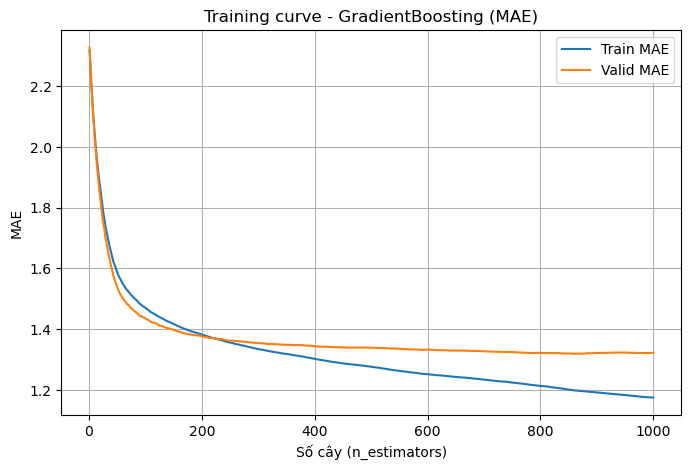

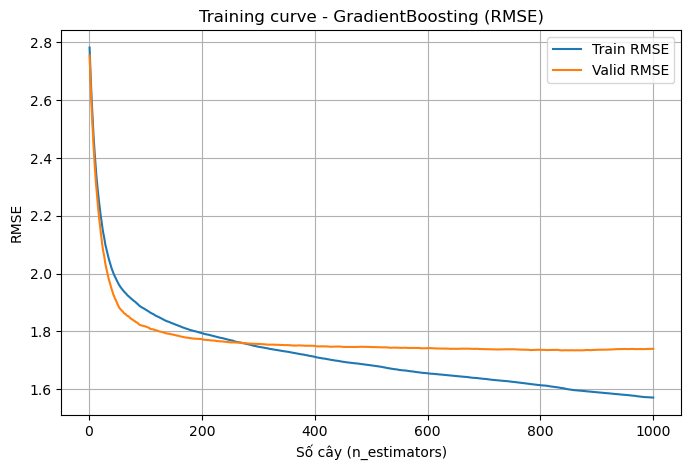

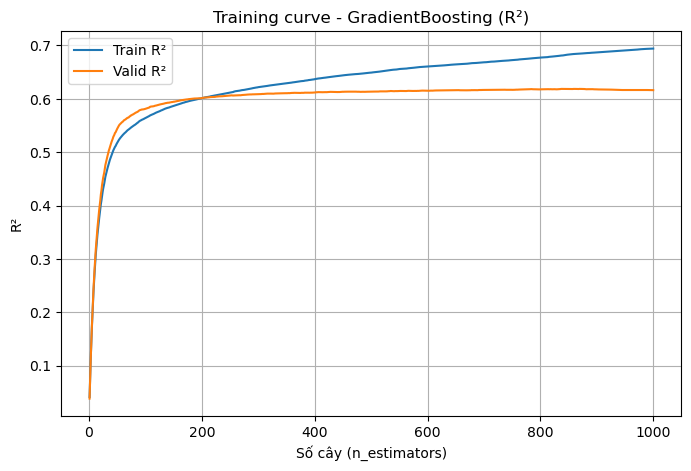

In [47]:
# =======================================
# 6c. Plot training curves cho GradientBoosting
# =======================================

# MAE train vs valid
plt.figure(figsize=(8, 5))
plt.plot(stages, train_mae_list, label="Train MAE")
plt.plot(stages, valid_mae_list, label="Valid MAE")
plt.xlabel("Số cây (n_estimators)")
plt.ylabel("MAE")
plt.title("Training curve - GradientBoosting (MAE)")
plt.legend()
plt.grid(True)
plt.savefig(os.path.join(save_dir, "Training curve - GradientBoosting (MAE).png"))
plt.show()

# RMSE train vs valid
plt.figure(figsize=(8, 5))
plt.plot(stages, train_rmse_list, label="Train RMSE")
plt.plot(stages, valid_rmse_list, label="Valid RMSE")
plt.xlabel("Số cây (n_estimators)")
plt.ylabel("RMSE")
plt.title("Training curve - GradientBoosting (RMSE)")
plt.legend()
plt.grid(True)
plt.savefig(os.path.join(save_dir, "Training curve - GradientBoosting (RMSE).png"))
plt.show()

# R² train vs valid
plt.figure(figsize=(8, 5))
plt.plot(stages, train_r2_list, label="Train R²")
plt.plot(stages, valid_r2_list, label="Valid R²")
plt.xlabel("Số cây (n_estimators)")
plt.ylabel("R²")
plt.title("Training curve - GradientBoosting (R²)")
plt.legend()
plt.grid(True)
plt.savefig(os.path.join(save_dir, "Training curve - GradientBoosting (R²).png"))
plt.show()


In [48]:
# =======================================
# 6d. Learning curve cho GradientBoosting (MAE ~ training size)
# =======================================

train_fracs = [0.1, 0.2, 0.4, 0.6, 0.8, 1.0]  # tỷ lệ dữ liệu train sử dụng
lc_results = []

# Để reproducible
rng = np.random.RandomState(42)
n_total = len(X)

for frac in train_fracs:
    n_sub = int(n_total * frac)
    idx_sub = rng.choice(n_total, size=n_sub, replace=False)

    X_sub = X.iloc[idx_sub]
    y_sub = y.iloc[idx_sub]

    # Split train/valid bên trong subset
    X_tr, X_val, y_tr, y_val = train_test_split(
        X_sub, y_sub, test_size=0.2, random_state=42
    )

    gb_lc = GradientBoostingRegressor(
        n_estimators=best_n_estimators if best_n_estimators is not None else 300,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    )
    gb_lc.fit(X_tr, y_tr)

    # Train metrics
    y_tr_pred = gb_lc.predict(X_tr)
    mae_tr = mean_absolute_error(y_tr, y_tr_pred)
    rmse_tr = np.sqrt(mean_squared_error(y_tr, y_tr_pred))
    r2_tr = r2_score(y_tr, y_tr_pred)

    # Valid metrics
    y_val_pred = gb_lc.predict(X_val)
    mae_val = mean_absolute_error(y_val, y_val_pred)
    rmse_val = np.sqrt(mean_squared_error(y_val, y_val_pred))
    r2_val = r2_score(y_val, y_val_pred)

    lc_results.append({
        "train_frac": frac,
        "n_train": len(X_tr),
        "MAE_train": mae_tr,
        "RMSE_train": rmse_tr,
        "R2_train": r2_tr,
        "MAE_valid": mae_val,
        "RMSE_valid": rmse_val,
        "R2_valid": r2_val
    })

    print(f"[LearningCurve] frac={frac:.1f} | n_train={len(X_tr)} | "
          f"MAE_valid={mae_val:.4f}, RMSE_valid={rmse_val:.4f}, R2_valid={r2_val:.4f}")

lc_df = pd.DataFrame(lc_results)
lc_df


[LearningCurve] frac=0.1 | n_train=388 | MAE_valid=1.4399, RMSE_valid=1.9161, R2_valid=0.5311
[LearningCurve] frac=0.2 | n_train=778 | MAE_valid=1.5400, RMSE_valid=2.0828, R2_valid=0.5010
[LearningCurve] frac=0.4 | n_train=1556 | MAE_valid=1.4399, RMSE_valid=1.8682, R2_valid=0.5581
[LearningCurve] frac=0.6 | n_train=2335 | MAE_valid=1.3833, RMSE_valid=1.8474, R2_valid=0.5967
[LearningCurve] frac=0.8 | n_train=3113 | MAE_valid=1.4173, RMSE_valid=1.8387, R2_valid=0.5932
[LearningCurve] frac=1.0 | n_train=3892 | MAE_valid=1.4534, RMSE_valid=1.9339, R2_valid=0.5431


,train_frac,n_train,MAE_train,RMSE_train,R2_train,MAE_valid,RMSE_valid,R2_valid
0,0.1,388,0.552705,0.855295,0.915067,1.439858,1.916064,0.531115
1,0.2,778,0.877545,1.217616,0.816684,1.540003,2.082813,0.500971
2,0.4,1556,1.053709,1.449927,0.745402,1.439852,1.868196,0.558131
3,0.6,2335,1.101139,1.490489,0.718152,1.383254,1.847402,0.596680
4,0.8,3113,1.143322,1.545187,0.701535,1.417336,1.838664,0.593159
5,1.0,3892,1.159403,1.546332,0.701027,1.453424,1.933922,0.543117


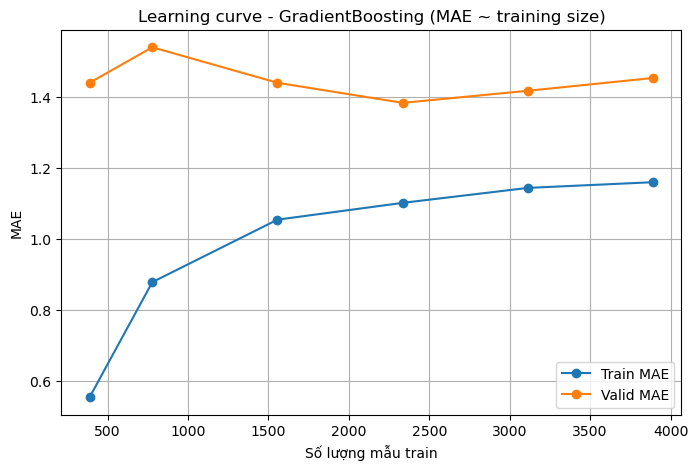

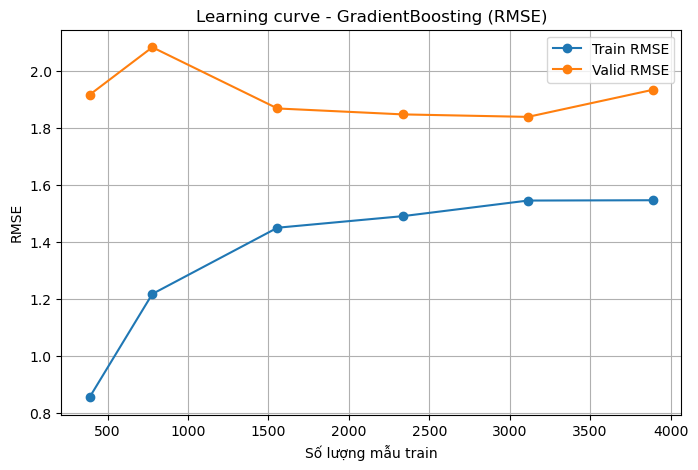

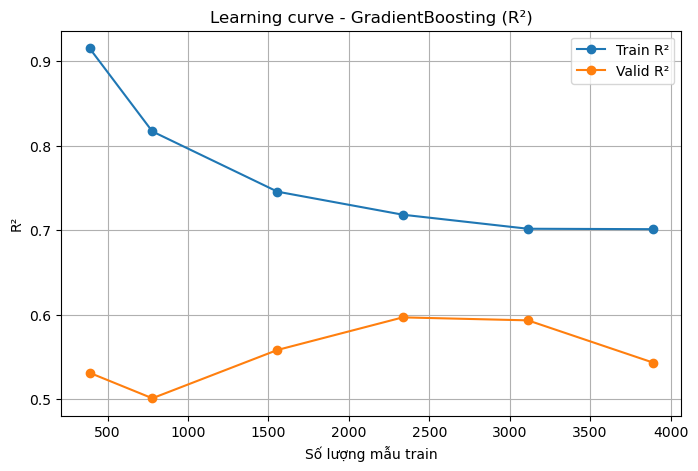

In [49]:
# MAE train & valid theo số lượng mẫu train
plt.figure(figsize=(8, 5))
plt.plot(lc_df["n_train"], lc_df["MAE_train"], marker="o", label="Train MAE")
plt.plot(lc_df["n_train"], lc_df["MAE_valid"], marker="o", label="Valid MAE")
plt.xlabel("Số lượng mẫu train")
plt.ylabel("MAE")
plt.title("Learning curve - GradientBoosting (MAE ~ training size)")
plt.legend()
plt.grid(True)
plt.savefig(os.path.join(save_dir, "Learning curve - GradientBoosting (MAE ~ training size).png"))
plt.show()

# (Optional) RMSE
plt.figure(figsize=(8, 5))
plt.plot(lc_df["n_train"], lc_df["RMSE_train"], marker="o", label="Train RMSE")
plt.plot(lc_df["n_train"], lc_df["RMSE_valid"], marker="o", label="Valid RMSE")
plt.xlabel("Số lượng mẫu train")
plt.ylabel("RMSE")
plt.title("Learning curve - GradientBoosting (RMSE)")
plt.legend()
plt.grid(True)
plt.savefig(os.path.join(save_dir, "Learning curve - GradientBoosting (RMSE).png"))
plt.show()

# (Optional) R²
plt.figure(figsize=(8, 5))
plt.plot(lc_df["n_train"], lc_df["R2_train"], marker="o", label="Train R²")
plt.plot(lc_df["n_train"], lc_df["R2_valid"], marker="o", label="Valid R²")
plt.xlabel("Số lượng mẫu train")
plt.ylabel("R²")
plt.title("Learning curve - GradientBoosting (R²)")
plt.legend()
plt.grid(True)
plt.savefig(os.path.join(save_dir, "Learning curve - GradientBoosting (R²).png"))
plt.show()


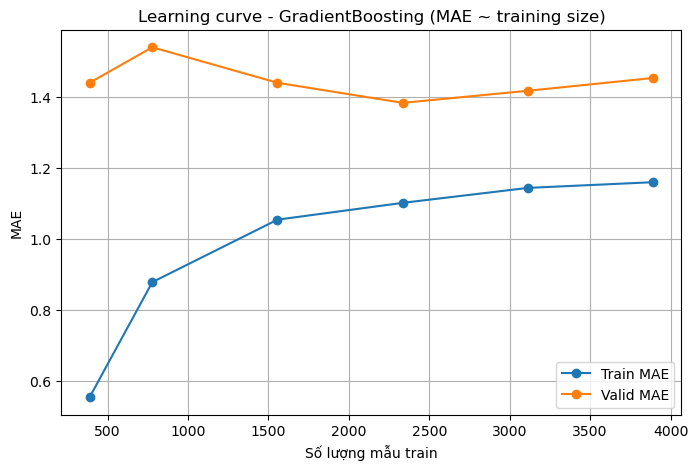

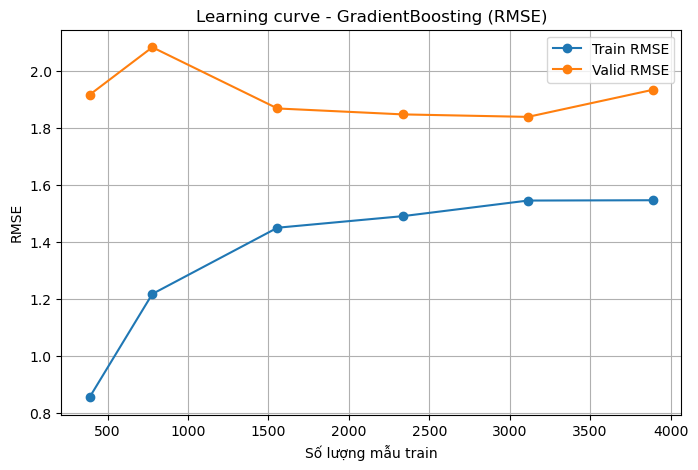

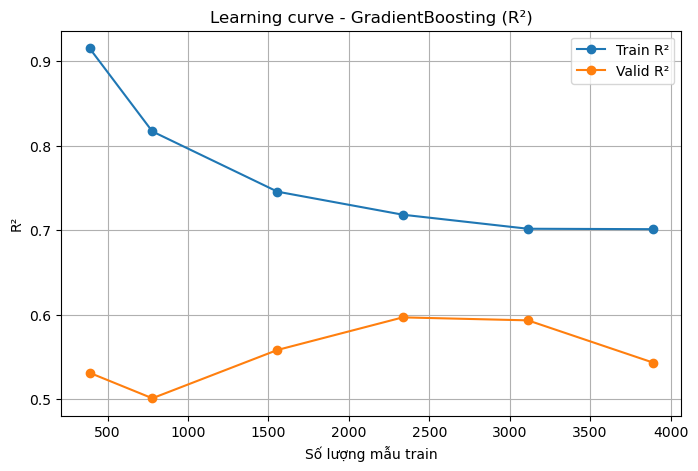

In [50]:
# MAE train & valid theo số lượng mẫu train
plt.figure(figsize=(8, 5))
plt.plot(lc_df["n_train"], lc_df["MAE_train"], marker="o", label="Train MAE")
plt.plot(lc_df["n_train"], lc_df["MAE_valid"], marker="o", label="Valid MAE")
plt.xlabel("Số lượng mẫu train")
plt.ylabel("MAE")
plt.title("Learning curve - GradientBoosting (MAE ~ training size)")
plt.legend()
plt.grid(True)
plt.savefig(os.path.join(save_dir, "Learning curve - GradientBoosting (MAE ~ training size).png"))
plt.show()

# (Optional) RMSE
plt.figure(figsize=(8, 5))
plt.plot(lc_df["n_train"], lc_df["RMSE_train"], marker="o", label="Train RMSE")
plt.plot(lc_df["n_train"], lc_df["RMSE_valid"], marker="o", label="Valid RMSE")
plt.xlabel("Số lượng mẫu train")
plt.ylabel("RMSE")
plt.title("Learning curve - GradientBoosting (RMSE)")
plt.legend()
plt.grid(True)
plt.savefig(os.path.join(save_dir, "Learning curve - GradientBoosting (RMSE).png"))
plt.show()

# (Optional) R²
plt.figure(figsize=(8, 5))
plt.plot(lc_df["n_train"], lc_df["R2_train"], marker="o", label="Train R²")
plt.plot(lc_df["n_train"], lc_df["R2_valid"], marker="o", label="Valid R²")
plt.xlabel("Số lượng mẫu train")
plt.ylabel("R²")
plt.title("Learning curve - GradientBoosting (R²)")
plt.legend()
plt.grid(True)
plt.savefig(os.path.join(save_dir, "Learning curve - GradientBoosting (R²).png"))
plt.show()


In [51]:
# =======================================
# 8b. Inference với fallback dựa trên course_R2 (GradientBoosting)
# =======================================

# Tạo map course -> (R2, n_valid)
course_stats = df_course_gb.set_index("course_code")[["R2", "n_valid"]].to_dict("index")

def get_course_r2_safe(course_code: str, min_n: int = 10):
    info = course_stats.get(course_code, None)
    if not info:
        return np.nan
    if info.get("n_valid", 0) < min_n:
        return np.nan
    return info.get("R2", np.nan)

# Gắn course_R2_gb vào từng dòng (lọc theo n_valid)
data["course_R2_gb"] = data["course_code"].apply(lambda c: get_course_r2_safe(c, min_n=10))

# Đảm bảo baseline đã có
if "baseline_final_weighted" not in data.columns:
    data["baseline_final_weighted"] = np.nan

# Nhất quán với train
data["baseline_final_weighted"] = data["baseline_final_weighted"].fillna(baseline_fill_value)

# Ngưỡng fallback
HIGH_R2 = 0.60
MID_R2  = 0.30
alpha = 0.7

# Không có R2 hợp lệ -> low-confidence
data["course_R2_gb"] = data["course_R2_gb"].fillna(-999)

# Khởi tạo
data["final_pred"] = np.nan
data["pred_source"] = "unknown"
data["confidence_level"] = "unknown"

mask_high = data["course_R2_gb"] >= HIGH_R2
mask_mid  = (data["course_R2_gb"] >= MID_R2) & (data["course_R2_gb"] < HIGH_R2)
mask_low  = data["course_R2_gb"] < MID_R2

# HIGH
data.loc[mask_high, "final_pred"] = data.loc[mask_high, "pred_final_gb"]
data.loc[mask_high, "pred_source"] = "gb_model"
data.loc[mask_high, "confidence_level"] = "high"

# MID: blend
data.loc[mask_mid, "final_pred"] = (
    alpha * data.loc[mask_mid, "pred_final_gb"] +
    (1 - alpha) * data.loc[mask_mid, "baseline_final_weighted"]
)
data.loc[mask_mid, "pred_source"] = "gb_baseline_blend"
data.loc[mask_mid, "confidence_level"] = "medium"

# LOW
data.loc[mask_low, "final_pred"] = data.loc[mask_low, "baseline_final_weighted"]
data.loc[mask_low, "pred_source"] = "baseline_only"
data.loc[mask_low, "confidence_level"] = "low"

print("\nSố lượng prediction theo confidence_level:")
print(data["confidence_level"].value_counts())

pred_csv_path_fallback = os.path.join(OUTPUT_DIR, "predictions_with_fallback_v2.csv")
data.to_csv(pred_csv_path_fallback, index=False, encoding="utf-8-sig")
print(f"Đã lưu dự đoán với fallback vào: {pred_csv_path_fallback}")



Số lượng prediction theo confidence_level:
confidence_level
low       1875
medium    1717
high      1273
Name: count, dtype: int64
Đã lưu dự đoán với fallback vào: ./output_final_v2\predictions_with_fallback_v2.csv


In [52]:
import joblib
import os

artifacts = {
    "gb_model": gb_model_es,
    "feature_cols": feature_cols,
    "mask_cols": mask_cols,
    "course_dummy_cols": list(course_dummies.columns),
    "baseline_fill_value": baseline_fill_value,
    "behavior_feature_cols": BEHAVIOR_FEATURE_BY_COURSE,
    "scaler_behavior": scaler_behavior,
}

ARTIFACTS_PATH = os.path.join(OUTPUT_DIR, "model_artifacts_gb_rf_add_feature1.joblib")
joblib.dump(artifacts, ARTIFACTS_PATH)
print("Đã lưu artifacts vào:", ARTIFACTS_PATH)


Đã lưu artifacts vào: ./output_final_v2\model_artifacts_gb_rf_add_feature1.joblib


In [53]:
model_path_pkl = os.path.join(OUTPUT_DIR, "model_artifacts_gb_rf_add_feature1.pkl")
joblib.dump(artifacts, model_path_pkl)
print(f"Đã lưu model & artifacts (pkl) vào: {model_path_pkl}")


Đã lưu model & artifacts (pkl) vào: ./output_final_v2\model_artifacts_gb_rf_add_feature1.pkl


In [54]:
def build_X_from_df_for_inference(
    df: pd.DataFrame,
    artifacts: dict,
    weights_by_course: Dict[str, Dict[str, float]],
    course_profile_scaled: pd.DataFrame
) -> (pd.DataFrame, pd.DataFrame):
    """
    Build X cho inference:
    - Tính baseline từ weights
    - Merge behavior feature theo course_code (đã scale)
    - Lấy đúng feature_cols + mask_cols + baseline
    - One-hot course_code
    """
    feature_cols = artifacts["feature_cols"]
    mask_cols = artifacts["mask_cols"]
    course_dummy_cols = artifacts["course_dummy_cols"]
    baseline_fill_value = artifacts.get("baseline_fill_value", 5.0)

    # 1) baseline từ weights
    df = add_baseline_from_weights(df, weights_by_course)

    if "baseline_final_weighted" not in df.columns:
        df["baseline_final_weighted"] = np.nan

    df["baseline_final_weighted"] = df["baseline_final_weighted"].fillna(baseline_fill_value)

    # 2) merge behavior feature (đã scale) theo course_code
    if course_profile_scaled is not None and not course_profile_scaled.empty:
        df = df.merge(course_profile_scaled, on="course_code", how="left")

    # 3) Numeric features
    X_num = df[feature_cols + mask_cols + ["baseline_final_weighted"]].copy()
    X_num = X_num.fillna(0.0)

    # 4) One-hot course_code
    course_dummies_new = pd.get_dummies(df["course_code"], prefix="course")

    for col in course_dummy_cols:
        if col not in course_dummies_new.columns:
            course_dummies_new[col] = 0
    course_dummies_new = course_dummies_new[course_dummy_cols]

    X_new = pd.concat([X_num, course_dummies_new], axis=1)

    return df, X_new


In [55]:
import joblib
import pandas as pd
import os

# 1. Load artifacts & weights
artifacts = joblib.load(os.path.join(OUTPUT_DIR, "model_artifacts_gb_rf_add_feature1.joblib"))
weights_by_course_inf = load_weights(WEIGHTS_FILE)

# 1.1. Build course_profile_scaled để dùng cho inference
course_profile_scaled_inf = build_scaled_course_profile_for_inference(
    artifacts=artifacts,
    behavior_path=BEHAVIOR_FILE
)

# 2. Nhận file upload (ví dụ CMU-CS 462.csv)
uploaded_path = os.path.join(DATA_DIR, "CMU-CS 462.csv")  # thay bằng path thực tế

# 3. Chuẩn hóa file (dùng cùng hàm với training)
df_course = load_and_process_course_file(uploaded_path)

# 4. Build X_new (NHỚ truyền thêm course_profile_scaled_inf)
df_features, X_new = build_X_from_df_for_inference(
    df_course,
    artifacts=artifacts,
    weights_by_course=weights_by_course_inf,
    course_profile_scaled=course_profile_scaled_inf
)

# 5. Chọn model (GB làm model chính)
gb_model_loaded = artifacts["gb_model"]
pred_final = gb_model_loaded.predict(X_new)
pred_final = np.clip(pred_final, 0.0, 10.0)  # giống inference chính

df_features["pred_final_gb"] = pred_final

# 6. Lưu kết quả
output_pred_path = os.path.join(OUTPUT_DIR, "pred_for_uploaded_CMU_CS_462_fixed.csv")
df_features.to_csv(output_pred_path, index=False, encoding="utf-8-sig")
print("Đã lưu dự đoán:", output_pred_path)


Đã load weights cho 52 course.
Đã build course_profile (mean/std/median) từ behavior file.
Số course_code có profile: 56
Đang đọc file: output_final_fixed\CMU-CS 462.csv
Đã lưu dự đoán: ./output_final_v2\pred_for_uploaded_CMU_CS_462_fixed.csv
